# Phase 3 — Improve the Model

**Goal:** Do three things to improve on Phase 2:
1. Find out which columns actually matter (Feature Importance)
2. Find the best settings for Random Forest (Hyperparameter Tuning)
3. Save the best model to a file so it can be used later

**Why this matters for interviews:**
"How did you improve your model?" is one of the most common ML interview questions.
After this notebook, you have a real answer: feature importance + hyperparameter tuning.

**Rule:** Run one cell at a time. Read every number. Think before moving on.

## Step 1 — Load Data and Recreate Train/Test Split

Same as Phase 2 — load the clean data and split it.
We use the same random_state=42 so we get the exact same split every time.
This is important: if the split changes, scores change, and comparisons are meaningless.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/telco_churn_clean.csv")

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows ✅")

Train: 5625 rows | Test: 1407 rows ✅


## Step 2 — Feature Importance

Random Forest can tell us: "out of all 30 columns, which ones did the trees use the most to make decisions?"

The more a column was used to split the data, the more important it is.

This answers the interview question: "Which features drove your model's predictions?"

We'll train a quick Random Forest first (default settings), then read its feature_importances_ values.

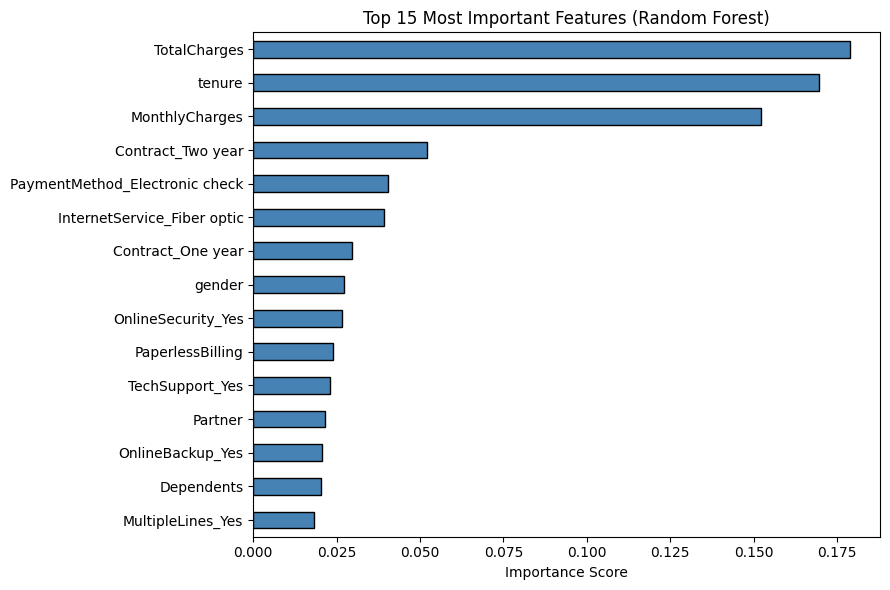


Top 10 features:
TotalCharges                      0.1789
tenure                            0.1697
MonthlyCharges                    0.1522
Contract_Two year                 0.0520
PaymentMethod_Electronic check    0.0403
InternetService_Fiber optic       0.0391
Contract_One year                 0.0297
gender                            0.0272
OnlineSecurity_Yes                0.0265
PaperlessBilling                  0.0241
dtype: float64


In [2]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Train a basic Random Forest just to read feature importances
rf_base = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf_base.fit(X_train, y_train)

# Get importance score for each feature — higher = used more by the trees
importance = pd.Series(rf_base.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

# Show top 15 features
top15 = importance.head(15)

plt.figure(figsize=(9, 6))
top15.plot(kind="barh", color="steelblue", edgecolor="black")
plt.gca().invert_yaxis()  # Most important at top
plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(top15.head(10).round(4))

# LOOK AT THIS CHART:
# Which column is #1? Does it match what you observed in Phase 1 EDA?
# (Hint: we predicted Contract type would be #1 — is it?)

## Step 3 — Hyperparameter Tuning with GridSearchCV

In Phase 2, Random Forest used default settings and got ~49% Recall.
Can we do better by finding the right settings?

**What are hyperparameters?**
Settings you choose BEFORE training. They are not learned from data — you set them manually.

| Hyperparameter | What it controls |
|---|---|
| `n_estimators` | How many trees in the forest |
| `max_depth` | How deep each tree can grow (deeper = learns more complex patterns) |
| `min_samples_split` | Minimum customers needed to make another split in a tree |

**What is GridSearchCV?**
It tries every combination of settings you give it, trains a model for each, and tells you which combination gave the best score.

Think of it as: "Try all oven temperatures and baking times, tell me which made the best cake."

⚠️ This cell takes 2-3 minutes to run — it is training many models. That is normal.

In [3]:
from sklearn.model_selection import GridSearchCV

# The settings we want to try
# GridSearchCV will try ALL combinations = 3 x 3 x 2 = 18 combinations
param_grid = {
    "n_estimators"    : [100, 200, 300],
    "max_depth"       : [5, 10, None],      # None = trees grow until pure
    "min_samples_split": [2, 10]
}

rf = RandomForestClassifier(class_weight="balanced", random_state=42)

# cv=5 means: for each combination, train 5 times on different data slices
# scoring="recall" means: pick the combination with the highest Recall
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1,           # use all CPU cores to speed up
    verbose=1
)

print("Starting grid search — trying 18 combinations x 5 folds = 90 models...")
print("This will take 2-3 minutes. Please wait...\n")

grid_search.fit(X_train, y_train)

print(f"\nBest settings found: {grid_search.best_params_}")
print(f"Best cross-validated Recall: {grid_search.best_score_:.2%}")

Starting grid search — trying 18 combinations x 5 folds = 90 models...
This will take 2-3 minutes. Please wait...

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best settings found: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validated Recall: 80.94%


## Step 4 — Evaluate the Best Model

GridSearchCV already knows the best settings. Now we test it on the test set and compare the results to Phase 2.

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Use the best model found by GridSearchCV
best_rf = grid_search.best_estimator_
rf_tuned_preds = best_rf.predict(X_test)

# Phase 2 Logistic Regression scores for comparison (from our earlier run)
phase2_lr_recall = 0.7968

tuned_accuracy  = accuracy_score(y_test,  rf_tuned_preds)
tuned_precision = precision_score(y_test, rf_tuned_preds)
tuned_recall    = recall_score(y_test,    rf_tuned_preds)
tuned_f1        = f1_score(y_test,        rf_tuned_preds)

print("=== Phase 3 — Tuned Random Forest vs Phase 2 Logistic Regression ===\n")
comparison = pd.DataFrame({
    "Metric"                    : ["Accuracy", "Precision", "Recall", "F1 Score"],
    "LR (Phase 2)"              : ["-", "-", f"{phase2_lr_recall:.2%}", "-"],
    "RF Tuned (Phase 3)"        : [f"{tuned_accuracy:.2%}", f"{tuned_precision:.2%}",
                                   f"{tuned_recall:.2%}", f"{tuned_f1:.2%}"]
})
print(comparison.to_string(index=False))

if tuned_recall > phase2_lr_recall:
    print(f"\n✅ Tuned Random Forest beats Logistic Regression on Recall!")
else:
    print(f"\n⚠️  Logistic Regression still has better Recall — it remains our best model.")

=== Phase 3 — Tuned Random Forest vs Phase 2 Logistic Regression ===

   Metric LR (Phase 2) RF Tuned (Phase 3)
 Accuracy            -             72.21%
Precision            -             48.64%
   Recall       79.68%             81.02%
 F1 Score            -             60.78%

✅ Tuned Random Forest beats Logistic Regression on Recall!


## Step 5 — Save the Best Model to a File

Right now the model only exists in memory — if you close the notebook, it's gone.

We save it to a `.pkl` file (pkl = pickle — Python's way of saving any object to disk).

**Why saving matters:**
- Phase 4 will load this file and wrap it in an API
- Engineers can use it without knowing Python or retraining
- This is how models go to production — save once, deploy anywhere

We save whichever model had the best Recall (LR or tuned RF).

In [5]:
import pickle
import os
from sklearn.linear_model import LogisticRegression

# Retrain Logistic Regression to compare (we need it in this notebook)
lr_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_recall = recall_score(y_test, lr_preds)

# Pick the winner based on Recall
if tuned_recall >= lr_recall:
    best_model = best_rf
    best_model_name = "Tuned Random Forest"
    best_recall = tuned_recall
else:
    best_model = lr_model
    best_model_name = "Logistic Regression"
    best_recall = lr_recall

print(f"Best model: {best_model_name}")
print(f"Best Recall: {best_recall:.2%}")

# Save to models/ folder
os.makedirs("../models", exist_ok=True)
model_path = "../models/best_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

print(f"\nModel saved to: {model_path} ✅")
print("To load it later: model = pickle.load(open('../models/best_model.pkl', 'rb'))")

Best model: Tuned Random Forest
Best Recall: 81.02%

Model saved to: ../models/best_model.pkl ✅
To load it later: model = pickle.load(open('../models/best_model.pkl', 'rb'))


C:\Users\ashishm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Your Observations — Fill This In

**Q1: What was the #1 most important feature according to Random Forest? Does it match what you predicted in EDA?**
total charges because if charge is more , customer will live

**Q2: What were the best hyperparameter settings found by GridSearchCV?**
max_depth , n_estimators , 

**Q3: Did tuning Random Forest beat Logistic Regression's Recall? By how much?**
_Your answer here_

**Q4: What is a .pkl file and why do we save the model?**
_Your answer here_

**Q5: If an interviewer asks "how did you improve your model?" — what would you say now?**
_Your answer here_

---
Paste your answers in the chat when done.
After this, we push to GitHub and move to Phase 4 — wrapping the model in an API so any application can use it.